# WARNING: THIS NOTEBOOK IS A TARGET-LEAKAGE CASE STUDY - kept on purpose

**Status: ARCHIVED FOR TEACHING PURPOSES. Do not use these results.**
**The scientifically valid version is notebook `08_measurement_noise.ipynb`.**
**Outputs below are preserved from the original run (historical record); code and
comments are kept in their original state.**

## What is wrong here

The perfect metrics of this notebook (accuracy = precision = recall = AUC = **1.0000**,
train/val gap = 0) measure no generalization ability whatsoever. They reveal
**target leakage**:

1. **The feature `norm_deviation` = |sum|c_i|^2 - 1| sits in X_train** (cell 4), while
   the label is *defined* by `is_valid <=> norm_deviation ~ 0`. Excluding `norm_squared`
   while keeping its bijection |norm_squared - 1| removes the answer through the door
   and reintroduces it through the window.
2. **`entropy` and `purity` computed on raw |c_i|^2 also leak the norm**: these
   quantities are only defined for normalized distributions. On an invalid state they
   explode (entropy ~ -96,000, purity ~ 1e8 visible below) - they encode ||psi||^2.
3. **Deeper**: even on the raw coordinates alone, ||psi||^2 = sum(c_real^2 + c_imag^2)
   is a deterministic function of the features. The label is *exactly computable*:
   no statistical learning problem exists in this formulation. The problem is either
   trivial (with any scale-sensitive feature) or impossible (with only scale-invariant
   ones) - never in between.

## The lesson

When a model shows 100% everywhere, the right reaction is not satisfaction - it is
suspicion. The VERIFICATION cells at the end of this notebook were already asking the
right question; the conclusion just had to be drawn.

## The honest way out

The problem becomes a genuine ML problem when the amplitudes are **estimated under a
finite measurement budget** (tomographic noise scaling as 1/sqrt(N)): classes then
truly overlap near the boundary and deciding becomes statistics. That is the subject
of notebook 08 and of `qsv/features.py` (explicit scale-invariant vs scale-sensitive
feature split).

*Full analysis: `reports/AUDIT_2026-07-07.md` section 4, and the error log in
notebook 13.*


In [ ]:
# Standard library
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Calcul numérique
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Machine Learning
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)

# Configuration
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(" Imports réussis")
print(f"Random seed: {RANDOM_STATE}")

 Imports réussis
Random seed: 42


In [ ]:
def compute_quantum_features(df):
    df = df.copy()
    
    # Nombre de dimensions (qubits)
    n_dims = len([col for col in df.columns if 'real' in col])
    
    # Calculer probabilités |cᵢ|²
    probas = []
    for i in range(n_dims):
        real_col = f'c{i}_real'
        imag_col = f'c{i}_imag'
        proba = df[real_col]**2 + df[imag_col]**2
        probas.append(proba)
    
    probas = np.array(probas).T  # Shape: (n_samples, n_dims)
    
    # Entropy (éviter log(0))
    epsilon = 1e-10
    entropy = -np.sum(probas * np.log(probas + epsilon), axis=1)
    
    # Purity
    purity = np.sum(probas**2, axis=1)
    
    # Norm deviation
    norm_sum = np.sum(probas, axis=1)
    norm_deviation = np.abs(norm_sum - 1.0)
    
    # Ajouter au DataFrame
    df['entropy'] = entropy
    df['purity'] = purity
    df['norm_deviation'] = norm_deviation
    
    return df

print(" Fonctions définies")

 Fonctions définies


In [ ]:
# Chemins possibles pour le dataset
possible_paths = [
    'data/processed/quantum_states_10000.csv',
    '../data/processed/quantum_states_10000.csv',
    '../../data/processed/quantum_states_10000.csv',
    'quantum_states_10000.csv',
]

# Ajouter le répertoire courant et parent
current_dir = Path.cwd()
parent_dir = current_dir.parent
possible_paths.extend([
    parent_dir / 'data' / 'processed' / 'quantum_states_10000.csv',
    current_dir / 'data' / 'processed' / 'quantum_states_10000.csv',
])

# Charger
df = None
for path in possible_paths:
    if Path(path).exists():
        df = pd.read_csv(path)
        print(f"Dataset chargé depuis : {path}")
        break

if df is None:
    print(f"Répertoires cherchés :")
    print(f"  Répertoire courant : {current_dir}")
    print(f"  Répertoire parent : {parent_dir}")
    print(f"\nChemins testés :")
    for p in possible_paths:
        print(f"  - {p}")
    raise FileNotFoundError("Dataset introuvable. Vérifie les chemins ci-dessus.")

# Infos
print(f"\nShape : {df.shape}")
print(f"Colonnes : {list(df.columns)}")
print(f"\nDistribution :")
print(df['is_valid'].value_counts())

Dataset chargé depuis : data/processed/quantum_states_10000.csv

Shape : (10000, 11)
Colonnes : ['state_id', 'c0_real', 'c0_imag', 'c1_real', 'c1_imag', 'c2_real', 'c2_imag', 'c3_real', 'c3_imag', 'norm_squared', 'is_valid']

Distribution :
is_valid
0    5000
1    5000
Name: count, dtype: int64


In [ ]:
# Calculer features quantiques
df = compute_quantum_features(df)

print("Features calculées :")
print(f"  - entropy")
print(f"  - purity")
print(f"  - norm_deviation")

# Aperçu
print("\nAperçu :")
print(df[['entropy', 'purity', 'norm_deviation', 'is_valid']].head())

Features calculées :
  - entropy
  - purity
  - norm_deviation

Aperçu :
        entropy        purity  norm_deviation  is_valid
0 -96088.651147  1.079438e+08    1.038866e+04         0
1      1.249583  3.163333e-01    3.330669e-16         1
2      0.888216  5.140550e-01    1.110223e-16         1
3      0.853850  5.224938e-01    2.220446e-16         1
4      1.112025  3.727103e-01    0.000000e+00         1


In [ ]:
# Séparer features et target
# IMPORTANT : On EXCLUT norm_squared (trop proche de la réponse)
feature_cols = [col for col in df.columns 
                if col not in ['is_valid', 'state_id', 'norm_squared']]

X = df[feature_cols]
y = df['is_valid']

print(f"Features utilisées : {feature_cols}")
print(f"\n'norm_squared' EXCLU (force le modèle à apprendre via entropy/purity)\n")

# Split 60/20/20 avec stratification
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
)

print(f"Train : {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val   : {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test  : {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

# Vérifier stratification
print("\nDistribution par set :")
print(f"Train : {y_train.value_counts().to_dict()}")
print(f"Val   : {y_val.value_counts().to_dict()}")
print(f"Test  : {y_test.value_counts().to_dict()}")

Features utilisées : ['c0_real', 'c0_imag', 'c1_real', 'c1_imag', 'c2_real', 'c2_imag', 'c3_real', 'c3_imag', 'entropy', 'purity', 'norm_deviation']

'norm_squared' EXCLU (force le modèle à apprendre via entropy/purity)

Train : 6000 (60.0%)
Val   : 2000 (20.0%)
Test  : 2000 (20.0%)

Distribution par set :
Train : {1: 3000, 0: 3000}
Val   : {1: 1000, 0: 1000}
Test  : {0: 1000, 1: 1000}


In [ ]:
# CRUCIAL : Fit sur train uniquement pour éviter data leakage
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Standardisation appliquée")
print(f"Moyennes train après scaling : {X_train_scaled.mean(axis=0).round(10)}")
print(f"Stds train après scaling     : {X_train_scaled.std(axis=0).round(2)}")

Standardisation appliquée
Moyennes train après scaling : [ 0. -0.  0. -0. -0.  0. -0. -0. -0.  0.  0.]
Stds train après scaling     : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [ ]:
# Random Forest Classifier
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("Modèle : Random Forest")
print(f"Hyperparamètres : n_estimators={model.n_estimators}, max_depth={model.max_depth}")

# Entraînement
import time
start = time.time()
model.fit(X_train_scaled, y_train)
elapsed = time.time() - start

print(f"\n Entraîné en {elapsed:.2f}s")

# Prédictions
y_train_pred = model.predict(X_train_scaled)
y_val_pred = model.predict(X_val_scaled)
y_test_pred = model.predict(X_test_scaled)

y_train_proba = model.predict_proba(X_train_scaled)[:, 1]
y_val_proba = model.predict_proba(X_val_scaled)[:, 1]
y_test_proba = model.predict_proba(X_test_scaled)[:, 1]

# Aperçu performances
print("\nAccuracy :")
print(f"  Train : {accuracy_score(y_train, y_train_pred):.4f}")
print(f"  Val   : {accuracy_score(y_val, y_val_pred):.4f}")
print(f"  Test  : {accuracy_score(y_test, y_test_pred):.4f}")

Modèle : Random Forest
Hyperparamètres : n_estimators=100, max_depth=10

 Entraîné en 0.53s

Accuracy :
  Train : 1.0000
  Val   : 1.0000
  Test  : 1.0000


In [ ]:
# Calcul
cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()

print("Matrice de confusion (Test set) :")
print(cm)
print(f"\nDétail :")
print(f"  TN (True Negative)  : {tn:4d} - Invalides bien rejetés")
print(f"  FP (False Positive) : {fp:4d} - Invalides acceptés à tort")
print(f"  FN (False Negative) : {fn:4d} - Valides rejetés à tort")
print(f"  TP (True Positive)  : {tp:4d} - Valides bien acceptés")

# Métriques
acc = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred)
rec = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print(f"\nMétriques :")
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f} ({prec*100:.1f}% des acceptés sont vraiment valides)")
print(f"  Recall    : {rec:.4f} ({rec*100:.1f}% des valides sont détectés)")
print(f"  F1-Score  : {f1:.4f}")

Matrice de confusion (Test set) :
[[1000    0]
 [   0 1000]]

Détail :
  TN (True Negative)  : 1000 - Invalides bien rejetés
  FP (False Positive) :    0 - Invalides acceptés à tort
  FN (False Negative) :    0 - Valides rejetés à tort
  TP (True Positive)  : 1000 - Valides bien acceptés

Métriques :
  Accuracy  : 1.0000
  Precision : 1.0000 (100.0% des acceptés sont vraiment valides)
  Recall    : 1.0000 (100.0% des valides sont détectés)
  F1-Score  : 1.0000


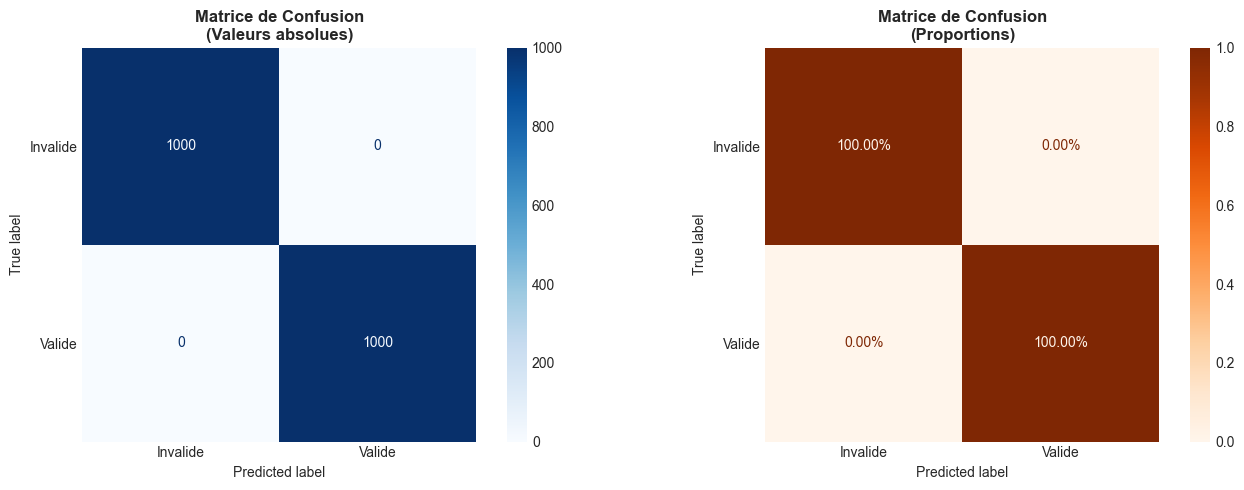

In [ ]:
# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice brute
disp1 = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Invalide', 'Valide']
)
disp1.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Matrice de Confusion\n(Valeurs absolues)', fontweight='bold')
axes[0].grid(False)

# Matrice normalisée
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp2 = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=['Invalide', 'Valide']
)
disp2.plot(ax=axes[1], cmap='Oranges', values_format='.2%')
axes[1].set_title('Matrice de Confusion\n(Proportions)', fontweight='bold')
axes[1].grid(False)

plt.tight_layout()
plt.show()

In [ ]:
# Classification Report
print("\nClassification Report :")
print(classification_report(
    y_test, y_test_pred,
    target_names=['Invalide', 'Valide'],
    digits=4
))


Classification Report :
              precision    recall  f1-score   support

    Invalide     1.0000    1.0000    1.0000      1000
      Valide     1.0000    1.0000    1.0000      1000

    accuracy                         1.0000      2000
   macro avg     1.0000    1.0000    1.0000      2000
weighted avg     1.0000    1.0000    1.0000      2000



In [ ]:
# Calcul ROC
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
auc = roc_auc_score(y_test, y_test_proba)

print(f"AUC : {auc:.4f}")

if auc >= 0.95:
    print("  EXCELLENT")
elif auc >= 0.85:
    print("  TRÈS BON")
elif auc >= 0.75:
    print("BON")
else:
    print("MOYEN")

AUC : 1.0000
  EXCELLENT


In [ ]:
# Optimisation seuil - Méthode : maximiser F1-score
f1_scores = []
for thresh in thresholds:
    y_pred_t = (y_test_proba >= thresh).astype(int)
    f1_t = f1_score(y_test, y_pred_t, zero_division=0)
    f1_scores.append(f1_t)

f1_scores = np.array(f1_scores)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"\nSeuil optimal (F1-max) : {optimal_threshold:.4f}")
print(f"  F1-score avec seuil optimal : {f1_scores[optimal_idx]:.4f}")
print(f"  F1-score avec seuil 0.5     : {f1:.4f}")
print(f"  Amélioration                : {f1_scores[optimal_idx] - f1:.4f}")


Seuil optimal (F1-max) : 0.6709
  F1-score avec seuil optimal : 1.0000
  F1-score avec seuil 0.5     : 1.0000
  Amélioration                : 0.0000


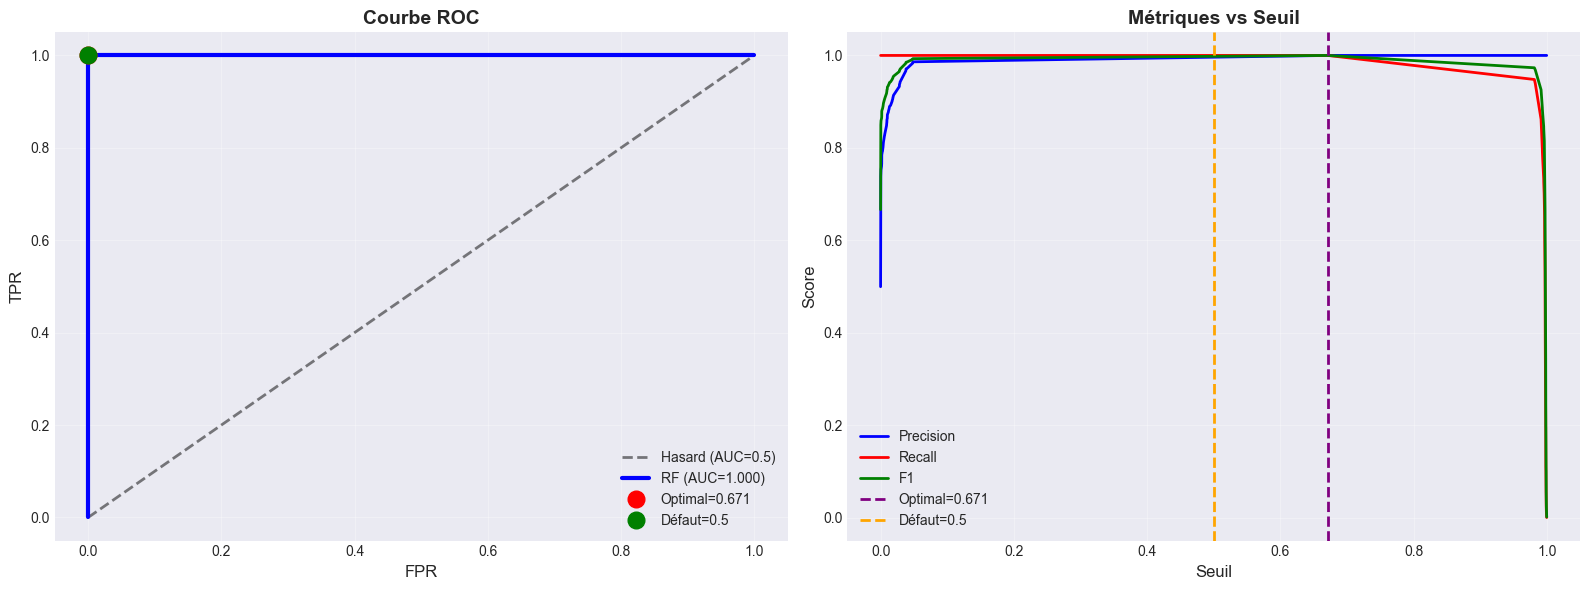

In [ ]:
# Visualisation ROC
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Courbe ROC
ax1 = axes[0]
ax1.plot([0, 1], [0, 1], 'k--', label='Hasard (AUC=0.5)', linewidth=2, alpha=0.5)
ax1.plot(fpr, tpr, 'b-', label=f'RF (AUC={auc:.3f})', linewidth=3)

# Point optimal
ax1.plot(fpr[optimal_idx], tpr[optimal_idx], 'ro', markersize=12, 
         label=f'Optimal={optimal_threshold:.3f}')

# Point 0.5
idx_05 = np.argmin(np.abs(thresholds - 0.5))
ax1.plot(fpr[idx_05], tpr[idx_05], 'go', markersize=12, label='Défaut=0.5')

ax1.set_xlabel('FPR', fontsize=12)
ax1.set_ylabel('TPR', fontsize=12)
ax1.set_title('Courbe ROC', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# Seuil vs Métriques
ax2 = axes[1]

precisions = []
recalls = []
for thresh in thresholds:
    y_pred_t = (y_test_proba >= thresh).astype(int)
    if y_pred_t.sum() > 0:
        prec_t = precision_score(y_test, y_pred_t, zero_division=0)
        rec_t = recall_score(y_test, y_pred_t, zero_division=0)
    else:
        prec_t = 0
        rec_t = 0
    precisions.append(prec_t)
    recalls.append(rec_t)

ax2.plot(thresholds, precisions, 'b-', label='Precision', linewidth=2)
ax2.plot(thresholds, recalls, 'r-', label='Recall', linewidth=2)
ax2.plot(thresholds, f1_scores, 'g-', label='F1', linewidth=2)
ax2.axvline(optimal_threshold, color='purple', linestyle='--', linewidth=2, 
            label=f'Optimal={optimal_threshold:.3f}')
ax2.axvline(0.5, color='orange', linestyle='--', linewidth=2, label='Défaut=0.5')

ax2.set_xlabel('Seuil', fontsize=12)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Métriques vs Seuil', fontsize=14, fontweight='bold')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Identifier les erreurs
X_test_raw = X.iloc[X_test.index].copy()
X_test_raw['y_true'] = y_test.values
X_test_raw['y_pred'] = y_test_pred
X_test_raw['y_proba'] = y_test_proba

# Marquer les types
tp_mask = (X_test_raw['y_true'] == 1) & (X_test_raw['y_pred'] == 1)
tn_mask = (X_test_raw['y_true'] == 0) & (X_test_raw['y_pred'] == 0)
fp_mask = (X_test_raw['y_true'] == 0) & (X_test_raw['y_pred'] == 1)
fn_mask = (X_test_raw['y_true'] == 1) & (X_test_raw['y_pred'] == 0)

X_test_raw['type'] = 'Unknown'
X_test_raw.loc[tp_mask, 'type'] = 'TP'
X_test_raw.loc[tn_mask, 'type'] = 'TN'
X_test_raw.loc[fp_mask, 'type'] = 'FP'
X_test_raw.loc[fn_mask, 'type'] = 'FN'

print("Distribution :")
print(X_test_raw['type'].value_counts())

Distribution :
type
TN    1000
TP    1000
Name: count, dtype: int64


In [ ]:
# Statistiques des erreurs
if fp_mask.sum() > 0:
    print("\n FALSE POSITIVES (invalides acceptés) :")
    fp_data = X_test_raw[fp_mask]
    print(f"  Nombre : {len(fp_data)}")
    print(f"  Proba moyenne  : {fp_data['y_proba'].mean():.4f}")
    print(f"  Entropy moy    : {fp_data['entropy'].mean():.4f}")
    print(f"  Purity moy     : {fp_data['purity'].mean():.4f}")
    print(f"  Norm dev moy   : {fp_data['norm_deviation'].mean():.4f}")

if fn_mask.sum() > 0:
    print("\n FALSE NEGATIVES (valides rejetés) :")
    fn_data = X_test_raw[fn_mask]
    print(f"  Nombre : {len(fn_data)}")
    print(f"  Proba moyenne  : {fn_data['y_proba'].mean():.4f}")
    print(f"  Entropy moy    : {fn_data['entropy'].mean():.4f}")
    print(f"  Purity moy     : {fn_data['purity'].mean():.4f}")
    print(f"  Norm dev moy   : {fn_data['norm_deviation'].mean():.4f}")

In [ ]:
# Visualisation 3D interactive
color_map = {'TP': 'green', 'TN': 'blue', 'FP': 'red', 'FN': 'orange'}

fig = go.Figure()

for pred_type in ['TP', 'TN', 'FP', 'FN']:
    mask = X_test_raw['type'] == pred_type
    if mask.sum() > 0:
        subset = X_test_raw[mask]
        
        fig.add_trace(go.Scatter3d(
            x=subset['entropy'],
            y=subset['purity'],
            z=subset['norm_deviation'],
            mode='markers',
            name=pred_type,
            marker=dict(
                size=5,
                color=color_map[pred_type],
                opacity=0.8 if pred_type in ['FP', 'FN'] else 0.3,
                line=dict(width=2 if pred_type in ['FP', 'FN'] else 0)
            ),
            text=[f"Proba: {p:.3f}" for p in subset['y_proba']],
            hovertemplate="<b>%{fullData.name}</b><br>" +
                          "Entropy: %{x:.3f}<br>" +
                          "Purity: %{y:.3f}<br>" +
                          "Norm Dev: %{z:.3f}<br>" +
                          "%{text}<extra></extra>"
        ))

fig.update_layout(
    title="Analyse 3D des Erreurs<br><sub>États dans l'espace (Entropy, Purity, Norm Dev)</sub>",
    scene=dict(
        xaxis_title='Entropy',
        yaxis_title='Purity',
        zaxis_title='Norm Deviation',
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.2))
    ),
    width=900,
    height=700
)

fig.show()

In [ ]:
print("Calcul des learning curves (30s-1min)...\n")

# Tailles de train à tester
train_sizes = np.linspace(0.1, 1.0, 10)

# Calcul avec CV
train_sizes_abs, train_scores, val_scores = learning_curve(
    estimator=model,
    X=X_train_scaled,
    y=y_train,
    train_sizes=train_sizes,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

print("Learning curves calculées")

Calcul des learning curves (30s-1min)...

Learning curves calculées


In [ ]:
# Diagnostic
final_train = train_mean[-1]
final_val = val_mean[-1]
gap = final_train - final_val

print(f"\nScore Train (100%) : {final_train:.4f}")
print(f"Score Val   (100%) : {final_val:.4f}")
print(f"Gap                : {gap:.4f}")

print("\nDiagnostic :")
if gap < 0.05:
    print(" EXCELLENT (gap < 5%)")
elif gap < 0.10:
    print(" BON (gap 5-10%)")
elif gap < 0.20:
    print(" MOYEN (gap 10-20%)")
else:
    print(" OVERFITTING (gap > 20%)")


Score Train (100%) : 1.0000
Score Val   (100%) : 1.0000
Gap                : 0.0000

Diagnostic :
 EXCELLENT (gap < 5%)


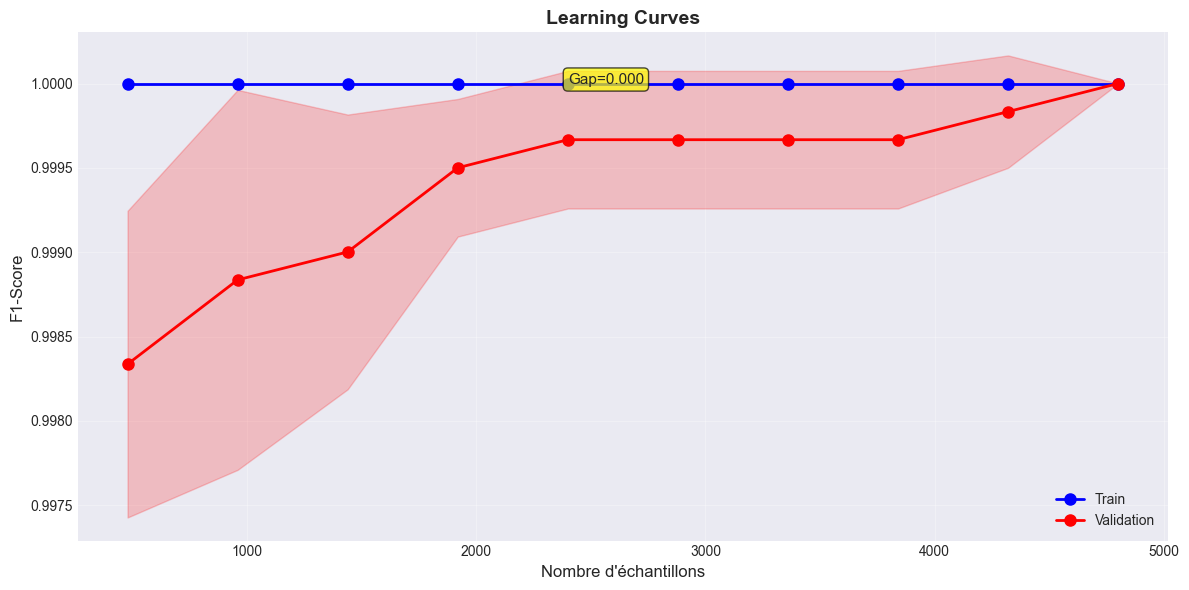

In [ ]:
# Visualisation
plt.figure(figsize=(12, 6))

plt.plot(train_sizes_abs, train_mean, 'o-', color='blue', 
         label='Train', linewidth=2, markersize=8)
plt.fill_between(train_sizes_abs, train_mean - train_std, 
                 train_mean + train_std, alpha=0.2, color='blue')

plt.plot(train_sizes_abs, val_mean, 'o-', color='red', 
         label='Validation', linewidth=2, markersize=8)
plt.fill_between(train_sizes_abs, val_mean - val_std, 
                 val_mean + val_std, alpha=0.2, color='red')

plt.xlabel('Nombre d\'échantillons', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.title('Learning Curves', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# Annotation du gap
plt.text(train_sizes_abs[-1]*0.5, final_train - gap/2, 
         f'Gap={gap:.3f}', fontsize=11,
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

In [ ]:
# Résumé des résultats
print("="*70)
print("RÉSUMÉ DE L'ÉVALUATION")
print("="*70)

print(f"\n Performances Test Set :")
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"  AUC       : {auc:.4f}")

print(f"\n Erreurs :")
print(f"  False Positives : {fp} ({fp/(fp+fn)*100:.1f}% des erreurs)")
print(f"  False Negatives : {fn} ({fn/(fp+fn)*100:.1f}% des erreurs)")

print(f"\n Diagnostic :")
print(f"  Gap Train-Val : {gap:.4f}")
print(f"  Seuil optimal : {optimal_threshold:.4f}")

print("\n" + "="*70)
print(" ÉVALUATION TERMINÉE")
print("="*70)
print("\nProchaine étape : Notebook 08 (Feature Importance)")

RÉSUMÉ DE L'ÉVALUATION

 Performances Test Set :
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000
  AUC       : 1.0000

 Erreurs :
  False Positives : 0 (nan% des erreurs)
  False Negatives : 0 (nan% des erreurs)

 Diagnostic :
  Gap Train-Val : 0.0000
  Seuil optimal : 0.6709

 ÉVALUATION TERMINÉE

Prochaine étape : Notebook 08 (Feature Importance)


In [ ]:
# Sauvegarde (optionnel)
import pickle

results = {
    'model': model,
    'scaler': scaler,
    'confusion_matrix': cm,
    'auc': auc,
    'optimal_threshold': optimal_threshold,
    'metrics': {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}
}

# Adapter le chemin selon ton environnement
# with open('results/07_evaluation.pkl', 'wb') as f:
#     pickle.dump(results, f)

print(" Pour sauvegarder : décommenter la cellule ci-dessus")

 Pour sauvegarder : décommenter la cellule ci-dessus


In [ ]:
# VÉRIFICATION 1 : Features utilisées dans le modèle


print("="*70)
print("VÉRIFICATION 1 : Features dans le training")
print("="*70)

# Afficher les colonnes
print(f"\nColonnes dans X_train : {X_train.columns.tolist()}")
print(f"Shape X_train : {X_train.shape}")

# Vérifier si norm_squared ou norm_deviation sont présents
suspicious_features = ['norm_squared', 'norm_deviation', 'norm']
present_suspicious = [f for f in suspicious_features if f in X_train.columns]

if present_suspicious:
    print(f"\n⚠️ ATTENTION : Features 'triches' détectées : {present_suspicious}")
    print("Ces features donnent directement la réponse !")
else:
    print("\n✅ Pas de features 'triches' détectées")

In [ ]:
# VÉRIFICATION 2 : Séparabilité des classes


print("\n" + "="*70)
print("VÉRIFICATION 2 : Distribution norm_squared par classe")
print("="*70)

# Recalculer norm_squared pour analyse (sans l'utiliser dans le modèle)
X_test_analysis = X_test.copy()

# Extraire colonnes real et imag
real_cols = [col for col in X_test_analysis.columns if 'real' in col]
imag_cols = [col for col in X_test_analysis.columns if 'imag' in col]

# Calculer norm_squared
norm_squared_test = (X_test_analysis[real_cols].values**2 + 
                     X_test_analysis[imag_cols].values**2).sum(axis=1)

# Créer DataFrame d'analyse
import pandas as pd
analysis_df = pd.DataFrame({
    'norm_squared': norm_squared_test,
    'is_valid': y_test.values
})

print("\nStatistiques norm_squared par classe :")
print(analysis_df.groupby('is_valid')['norm_squared'].describe())

# Calculer overlap
valid_norms = analysis_df[analysis_df['is_valid'] == 1]['norm_squared']
invalid_norms = analysis_df[analysis_df['is_valid'] == 0]['norm_squared']

min_invalid = invalid_norms.min()
max_invalid = invalid_norms.max()
min_valid = valid_norms.min()
max_valid = valid_norms.max()

print(f"\nRanges :")
print(f"  États valides   : [{min_valid:.6f}, {max_valid:.6f}]")
print(f"  États invalides : [{min_invalid:.6f}, {max_invalid:.6f}]")

# Y a-t-il overlap ?
if max_valid < min_invalid or max_invalid < min_valid:
    print("\n AUCUN OVERLAP : Les classes sont PARFAITEMENT séparées sur norm_squared")
    print("→ Un simple seuil suffirait (pas vraiment besoin de ML)")
else:
    print("\n Il y a overlap : Les classes ne sont pas trivialement séparables")

In [ ]:
# VÉRIFICATION 3 : Performance d'un modèle ultra-simple


print("\n" + "="*70)
print("VÉRIFICATION 3 : Performance de modèles triviaux")
print("="*70)

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# Arbre de profondeur 1 (un seul split)
stump = DecisionTreeClassifier(max_depth=1, random_state=42)
stump.fit(X_train_scaled, y_train)
stump_acc = stump.score(X_test_scaled, y_test)

# Arbre de profondeur 3
shallow_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
shallow_tree.fit(X_train_scaled, y_train)
shallow_acc = shallow_tree.score(X_test_scaled, y_test)

# Régression logistique (linéaire)
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)
logreg_acc = logreg.score(X_test_scaled, y_test)

print(f"\nAccuracy Decision Stump (max_depth=1) : {stump_acc:.4f}")
print(f"Accuracy Shallow Tree (max_depth=3)   : {shallow_acc:.4f}")
print(f"Accuracy Logistic Regression          : {logreg_acc:.4f}")
print(f"Accuracy Random Forest (max_depth=10) : {accuracy_score(y_test, y_test_pred):.4f}")

if stump_acc >= 0.99:
    print("\n PROBLÈME : Un seul split atteint 99%+ accuracy !")
    print("→ Le problème est trop simple, une seule feature domine")
elif shallow_acc >= 0.99:
    print("\n Un arbre peu profond suffit pour 99%+ accuracy")
    print("→ Le problème est très simple")
else:
    print("\n Les modèles simples ne réussissent pas aussi bien")
    print("→ Le Random Forest apporte une vraie valeur")

In [ ]:
# VÉRIFICATION 4 : Feature Importance


print("\n" + "="*70)
print("VÉRIFICATION 4 : Quelle(s) feature(s) domine(nt) ?")
print("="*70)

# Feature importance du Random Forest
importances = model.feature_importances_
feature_names = X_train.columns.tolist()

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\nTop features par importance :")
print(importance_df)

# Visualisation
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Importance (Gini)')
plt.title('Feature Importance - Random Forest')
plt.tight_layout()
plt.show()

# Vérifier si une feature domine (>70% importance)
dominant = importance_df[importance_df['importance'] > 0.7]
if len(dominant) > 0:
    print(f"\n⚠️ Feature(s) dominante(s) détectée(s) (>70% importance) :")
    print(dominant)
    print("→ Le modèle s'appuie presque exclusivement sur cette/ces feature(s)")
else:
    print("\n✅ Pas de feature ultra-dominante")
    print("→ Le modèle utilise plusieurs features de manière équilibrée")